<a href="https://colab.research.google.com/github/Elvin100s/Formative/blob/master/Assignment1_ElvinCyubahiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classical ML vs. Neural Network from Scratch: Predicting Chronic Kidney Disease

**Author:** Elvin Cyubahiro
**Course:** Introduction to Machine Learning
**Date:** May 2026
**Dataset:** Soundarapandian & Rubini (2015), UCI Machine Learning Repository

This notebook compares classical machine learning models (logistic regression and random forest) against a feedforward neural network I built from scratch in NumPy. The goal is binary classification — predicting whether a patient has chronic kidney disease (CKD) based on clinical features. I evaluate everything using accuracy, precision, recall, and F1-score on the UCI CKD dataset (Soundarapandian & Rubini, 2015).

## 1. Library Imports and Environment Configuration

Below I import everything needed for the project. NumPy and Pandas handle the data, Matplotlib and Seaborn handle plotting, and scikit-learn provides the classical ML models and evaluation metrics (Pedregosa et al., 2011). The `ucimlrepo` package pulls the dataset directly. No deep learning frameworks are used — the neural network in Section 5 is pure NumPy.

In [31]:
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Global dictionary to accumulate results from all models
all_results = {}

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Selection and Justification

Chronic kidney disease is a major global health issue — it affects about 9.1% of adults worldwide and caused around 1.2 million deaths in 2017 (Bikbov et al., 2020). The tricky part is that CKD is mostly asymptomatic until the later stages, so catching it early from routine lab work is really valuable clinically.

The dataset I'm using was collected at Apollo Hospitals in India and is hosted on the UCI ML Repository (Soundarapandian & Rubini, 2015). It has 400 patient records with 24 features covering demographics (age, blood pressure), urine tests (specific gravity, albumin, red blood cells), blood chemistry (haemoglobin, serum creatinine, blood glucose, sodium, potassium), and comorbidity flags (hypertension, diabetes, coronary artery disease). The target is binary: CKD or not CKD.

I picked this dataset for a few reasons. First, it's a binary classification problem that works well with both linear and non-linear models. Second, the 24 features are clinically interpretable, so I can actually reason about what the models are learning. Third, the size (400 × 24) is manageable for a NumPy-only neural network without needing GPU compute. Fourth, there's a decent amount of missing data, which forces me to think about imputation. And fifth, the class imbalance (~62.5% CKD, ~37.5% not-CKD) means I need to look beyond just accuracy.

For preprocessing I use median imputation for continuous features since it's robust to outliers (Little & Rubin, 2002), mode imputation for categoricals, one-hot encoding with `drop_first=True` to avoid multicollinearity (Bishop, 2006, p. 296), and `StandardScaler` normalisation for the gradient-based methods. I report precision, recall, and F1 alongside accuracy because in a medical context, both false alarms and missed diagnoses matter (van Rijsbergen, 1979).

## 3. Data Loading and Preprocessing

### 3.1 Data Loading

I fetch the dataset using the `ucimlrepo` package with its repository ID (336). The cell below loads it and prints the shape, column types, and how much data is missing.

In [32]:
# Load the Chronic Kidney Disease dataset from UCI ML Repository
ckd = fetch_ucirepo(id=336)
X = ckd.data.features
y = ckd.data.targets

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nTarget value counts:")
target_series = y.iloc[:, 0].astype(str).str.strip()
print(target_series.value_counts())

print("\n" + "=" * 60)
print("FIRST 5 ROWS OF FEATURES")
print("=" * 60)
display(X.head())

print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(X.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
missing = X.isnull().sum()
missing_pct = (X.isnull().sum() / len(X) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False)
display(missing_df)
print(f"\nTotal missing cells: {X.isnull().sum().sum()} "
      f"out of {X.shape[0] * X.shape[1]} "
      f"({X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.1f}%)")

DATASET OVERVIEW
Feature matrix shape: (400, 24)
Target vector shape:  (400, 1)

Target value counts:
class
ckd       250
notckd    150
Name: count, dtype: int64

FIRST 5 ROWS OF FEATURES


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no



COLUMN DATA TYPES
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc       object
pc        object
pcc       object
ba        object
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn       object
dm        object
cad       object
appet     object
pe        object
ane       object
dtype: object

MISSING VALUES PER COLUMN


,Missing Count,Missing %
rbc,152,38.0
rbcc,131,32.8
wbcc,106,26.5
pot,88,22.0
sod,87,21.8
pcv,71,17.8
pc,65,16.2
hemo,52,13.0
su,49,12.2
sg,47,11.8



Total missing cells: 1012 out of 9600 (10.5%)


### 3.2 Exploratory Data Analysis

Before doing any preprocessing, I want to understand what I'm working with — class balance, how key clinical variables are distributed, correlations between features, and where the missing values are.

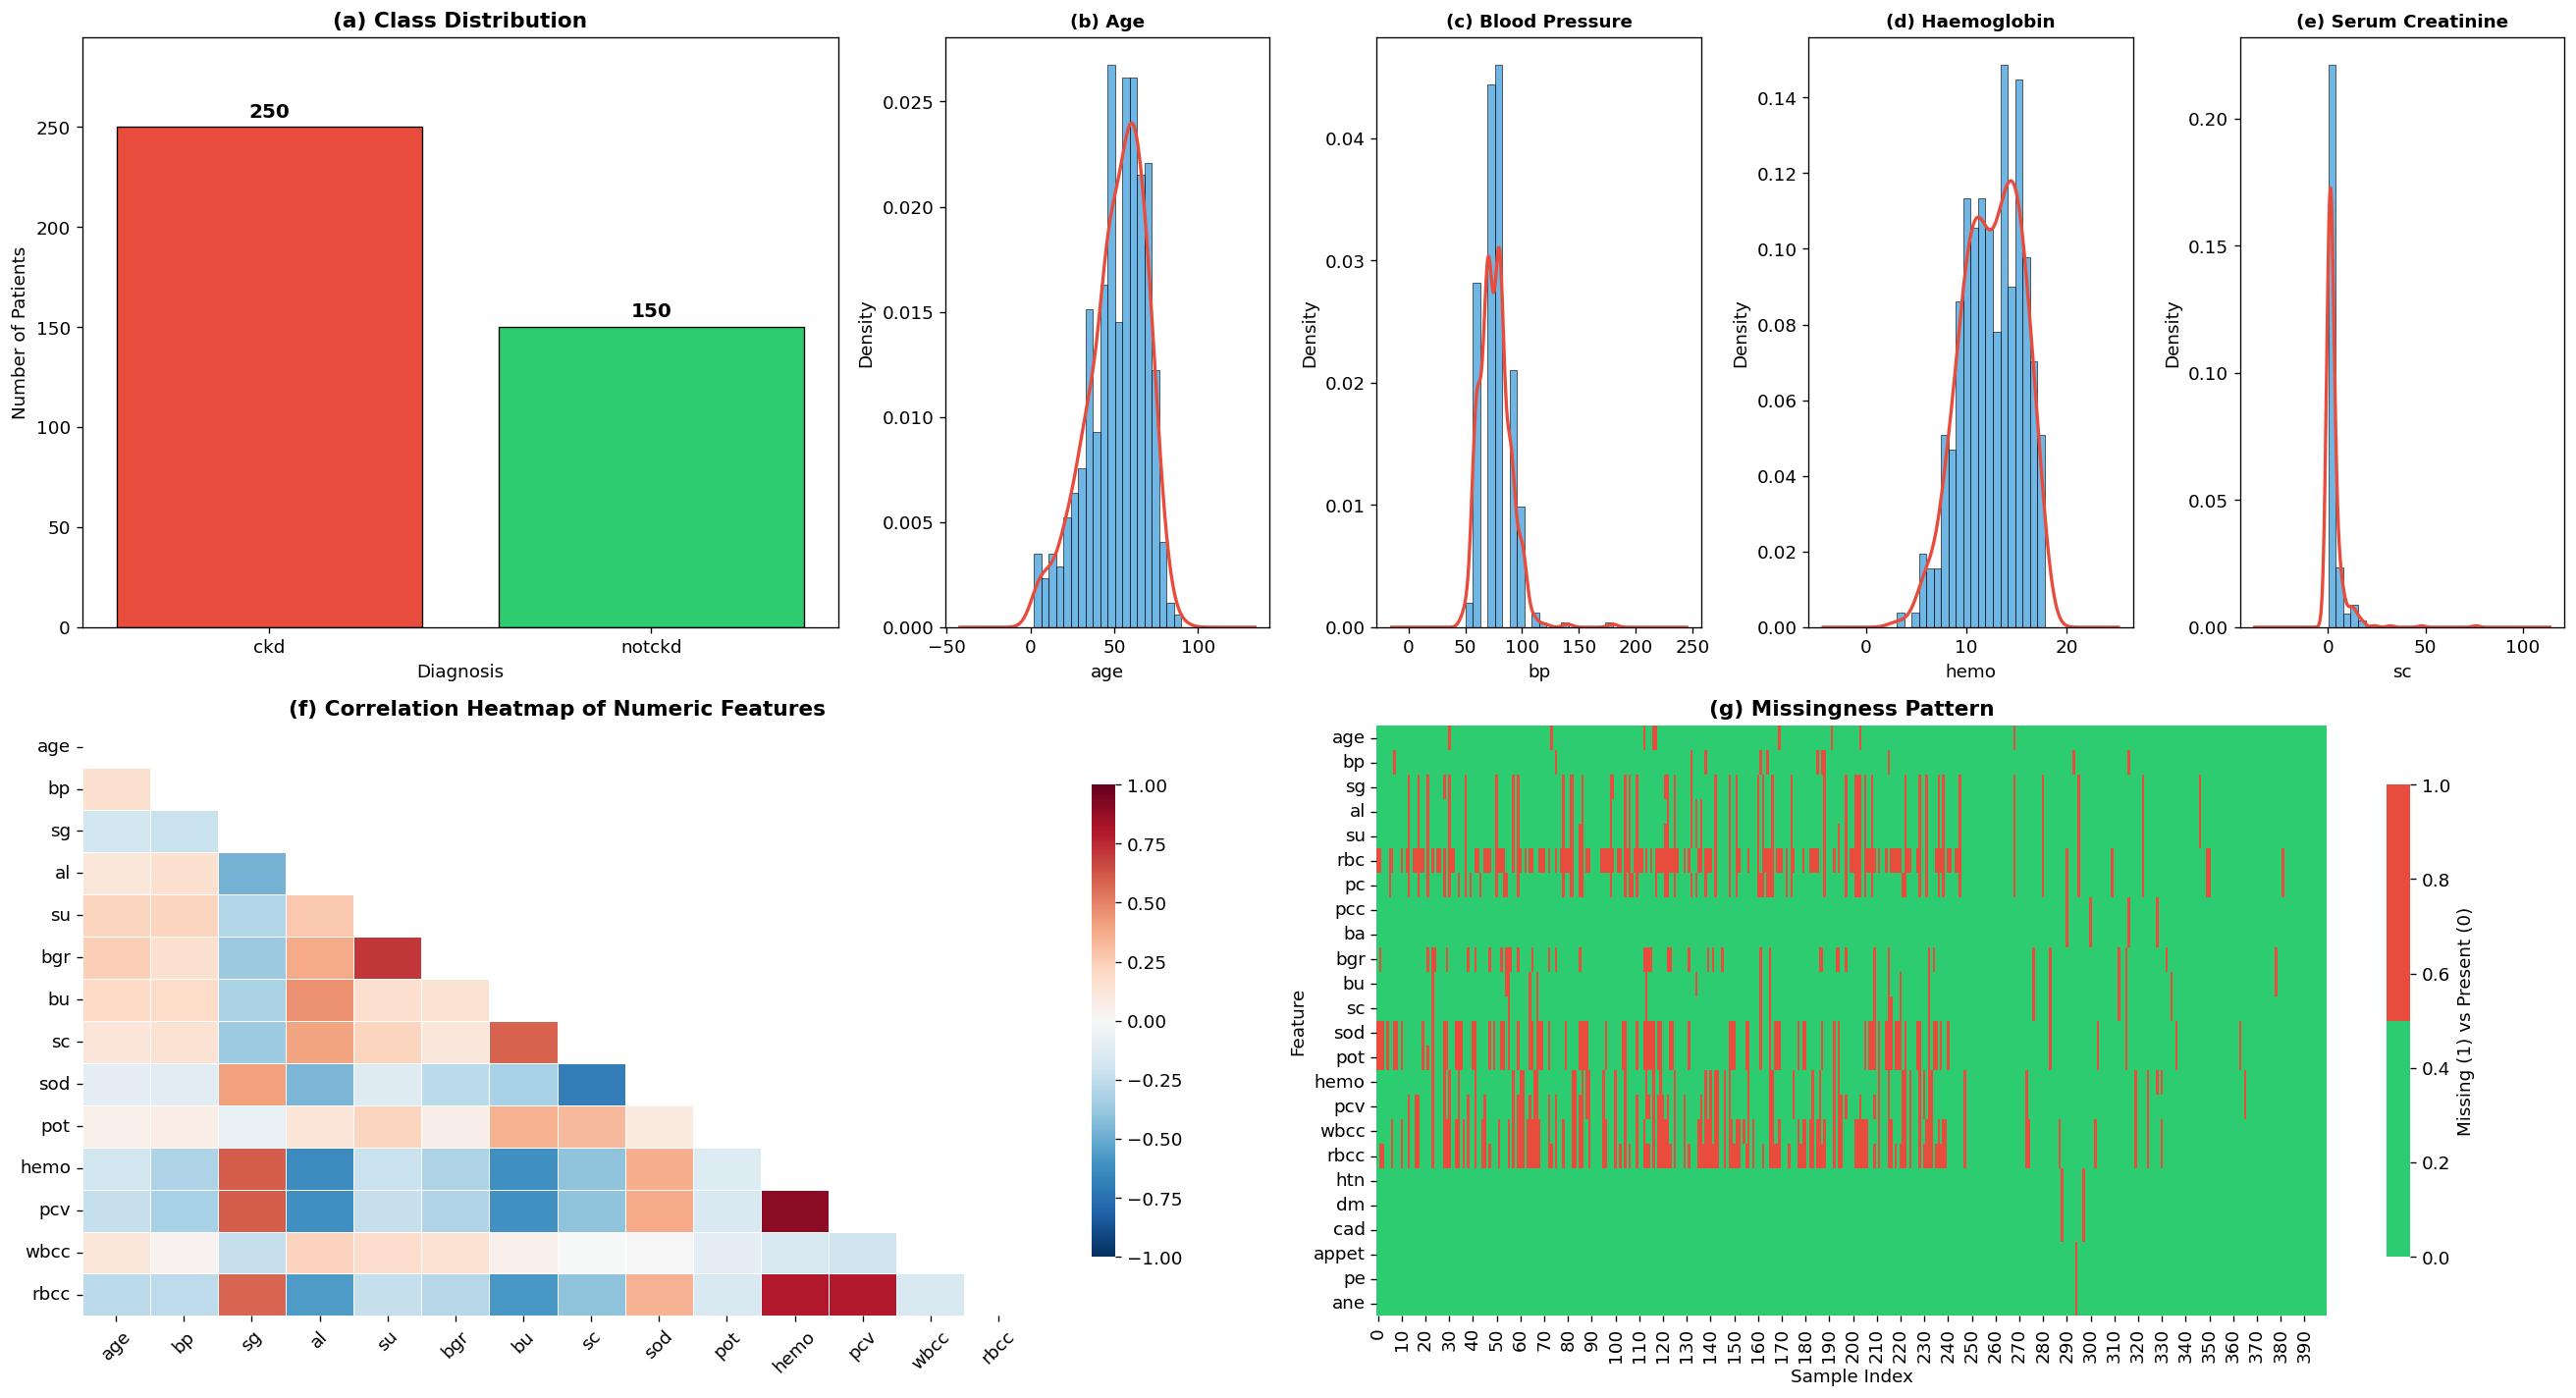

In [33]:
# Prepare target series for EDA
y_temp = y.iloc[:, 0].astype(str).str.strip()

# Identify numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

fig = plt.figure(figsize=(22, 12))

# --- Panel 1: Class distribution (row 0, cols 0-1) ---
ax_class = plt.subplot2grid((2, 6), (0, 0), colspan=2)
class_counts = y_temp.value_counts()
bars = ax_class.bar(class_counts.index.astype(str), class_counts.values,
                    color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8)
for bar_rect, count in zip(bars, class_counts.values):
    ax_class.text(bar_rect.get_x() + bar_rect.get_width() / 2., bar_rect.get_height() + 3,
                  str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax_class.set_title('(a) Class Distribution', fontweight='bold')
ax_class.set_xlabel('Diagnosis')
ax_class.set_ylabel('Number of Patients')
ax_class.set_ylim(0, max(class_counts.values) * 1.18)

# --- Panels 2-5: Key continuous feature distributions ---
key_feats = [c for c in ['age', 'bp', 'hemo', 'sc'] if c in X.columns]
titles = ['(b) Age', '(c) Blood Pressure', '(d) Haemoglobin', '(e) Serum Creatinine']
for i, (feat, title) in enumerate(zip(key_feats, titles)):
    ax = plt.subplot2grid((2, 6), (0, 2 + i))
    col_data = pd.to_numeric(X[feat], errors='coerce').dropna()
    ax.hist(col_data, bins=20, color='#3498db', edgecolor='black',
            linewidth=0.5, alpha=0.7, density=True)
    col_data.plot.kde(ax=ax, color='#e74c3c', linewidth=2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(feat)
    if i == 0:
        ax.set_ylabel('Density')

# --- Panel 6: Correlation heatmap (row 1, cols 0-2) ---
ax_corr = plt.subplot2grid((2, 6), (1, 0), colspan=3)
numeric_data = X[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr = numeric_data.corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax_corr, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax_corr.set_title('(f) Correlation Heatmap of Numeric Features', fontweight='bold')
ax_corr.tick_params(axis='x', rotation=45)

# --- Panel 7: Missingness pattern (row 1, cols 3-5) ---
ax_miss = plt.subplot2grid((2, 6), (1, 3), colspan=3)
cols_with_missing = X.columns[X.isnull().any()].tolist()
if len(cols_with_missing) > 0:
    missing_matrix = X[cols_with_missing].isnull().astype(int)
    sns.heatmap(missing_matrix.T, cmap=['#2ecc71', '#e74c3c'],
                cbar_kws={'label': 'Missing (1) vs Present (0)', 'shrink': 0.8},
                ax=ax_miss, yticklabels=True)
    ax_miss.set_title('(g) Missingness Pattern', fontweight='bold')
    ax_miss.set_xlabel('Sample Index')
    ax_miss.set_ylabel('Feature')
else:
    ax_miss.text(0.5, 0.5, 'No missing values detected',
                 transform=ax_miss.transAxes, ha='center', fontsize=14)

plt.tight_layout()
plt.show()

**What this tells us.** Panel (a) shows the class imbalance — roughly 250 CKD cases vs. 150 non-CKD. Haemoglobin (panel d) has a clear bimodal shape, which makes sense because CKD patients tend to be anaemic while healthy patients aren't. Serum creatinine (panel e) is heavily right-skewed with some extreme outliers — those are patients with severely impaired kidney function.

The correlation heatmap shows expected patterns: haemoglobin correlates with packed cell volume and red blood cell count (they're physiologically linked), and serum creatinine correlates with blood urea (both are renal function markers). The missingness heatmap reveals that red blood cell count, white blood cell count, and potassium have the most missing values, which supports using imputation rather than just dropping incomplete rows.

### 3.3 Preprocessing Pipeline

The pipeline below does eight things: (1) separates numeric and categorical columns, (2) coerces numeric types, (3) cleans up categorical values, (4) median-imputes numerics and mode-imputes categoricals using `SimpleImputer` (Little & Rubin, 2002), (5) one-hot encodes categoricals with `drop_first=True` (Bishop, 2006), (6) encodes the target as binary (CKD = 1), (7) does a stratified 80/20 train-test split, and (8) fits `StandardScaler` on training data only so there's no data leakage (Hastie et al., 2009, Ch. 7).

In [34]:
# Step 1: Define expected column types based on clinical knowledge
# Note: UCI CKD dataset uses 'wbcc' and 'rbcc' for white/red blood cell counts
numeric_features = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc',
                    'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
categorical_features = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad',
                        'appet', 'pe', 'ane']

# Filter to columns that actually exist in the loaded dataset
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in categorical_features if c in X.columns]

X_proc = X.copy()

# Step 2: Coerce numeric columns to proper dtype
for col in numeric_features:
    X_proc[col] = pd.to_numeric(X_proc[col], errors='coerce')

# Step 3: Clean categorical columns
for col in categorical_features:
    X_proc[col] = X_proc[col].astype(str).str.strip()
    X_proc[col] = X_proc[col].replace(
        {'nan': np.nan, 'None': np.nan, '?': np.nan, '': np.nan})

# Step 4: Impute missing values
num_imputer = SimpleImputer(strategy='median')
X_proc[numeric_features] = pd.DataFrame(
    num_imputer.fit_transform(X_proc[numeric_features]),
    columns=numeric_features, index=X_proc.index)

cat_imputer = SimpleImputer(strategy='most_frequent')
X_proc[categorical_features] = pd.DataFrame(
    cat_imputer.fit_transform(X_proc[categorical_features]),
    columns=categorical_features, index=X_proc.index)

# Step 5: One-hot encode categorical features
X_encoded = pd.get_dummies(X_proc, columns=categorical_features, drop_first=True)
feature_names = X_encoded.columns.tolist()

# Step 6: Encode target variable
y_encoded = (y.iloc[:, 0].astype(str).str.strip() == 'ckd').astype(int).values

# Step 7: Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded, test_size=0.2,
    stratify=y_encoded, random_state=42)

# Step 8: Standardize features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Verify no NaN values remain
assert not np.isnan(X_train).any(), "X_train still contains NaN!"
assert not np.isnan(X_test).any(), "X_test still contains NaN!"

print("Preprocessing complete.")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Number of features after encoding: {len(feature_names)}")
print(f"\nTraining set class distribution:")
print(f"  CKD (1):     {np.sum(y_train == 1)} ({np.mean(y_train == 1)*100:.1f}%)")
print(f"  Not CKD (0): {np.sum(y_train == 0)} ({np.mean(y_train == 0)*100:.1f}%)")
print(f"\nTest set class distribution:")
print(f"  CKD (1):     {np.sum(y_test == 1)} ({np.mean(y_test == 1)*100:.1f}%)")
print(f"  Not CKD (0): {np.sum(y_test == 0)} ({np.mean(y_test == 0)*100:.1f}%)")

Preprocessing complete.

X_train shape: (320, 24)
X_test shape:  (80, 24)
y_train shape: (320,)
y_test shape:  (80,)
Number of features after encoding: 24

Training set class distribution:
  CKD (1):     200 (62.5%)
  Not CKD (0): 120 (37.5%)

Test set class distribution:
  CKD (1):     50 (62.5%)
  Not CKD (0): 30 (37.5%)


## 4. Classical Machine Learning Models

Classical models learn a direct mapping from features to labels over a fixed feature representation — they don't learn the representation itself like neural networks do (Goodfellow et al., 2016). I'm evaluating two classifiers with different inductive biases: logistic regression (linear boundary, convex optimisation) and random forest (non-linear ensemble of trees). Both are well-understood theoretically and widely used in clinical prediction (Hastie et al., 2009). The helper function below standardises evaluation across all experiments.

In [35]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit a classical model, evaluate on test set, store results, and plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    all_results[name] = {'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1}

    # Store probabilities for ROC curve plotting later
    if y_prob is not None:
        all_results[name]['y_prob'] = y_prob
        all_results[name]['y_true'] = y_te

    print(f"\n{'=' * 55}")
    print(f"  {name} — Classification Report")
    print(f"{'=' * 55}")
    print(classification_report(y_te, y_pred, target_names=['Not CKD', 'CKD']))

    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return model

print("Evaluation helper function defined.")

Evaluation helper function defined.


### 4.1 Logistic Regression

Logistic regression models $P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$ where $\sigma$ is the logistic sigmoid. It finds parameters by minimising binary cross-entropy via L-BFGS (Bishop, 2006, Ch. 4). The regularisation parameter $C = 1/\lambda$ controls the bias-variance trade-off — small $C$ means strong $\ell_2$ penalty (high bias, low variance), large $C$ lets the model fit more freely. This assumes a linear decision boundary, which might be enough if the preprocessed features make the classes roughly linearly separable. I test three values of $C$.

**Experiment LR-1 ($C = 1.0$, baseline).** Default regularisation — a moderate balance between fitting the data and constraining the weights.


  LR-1 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



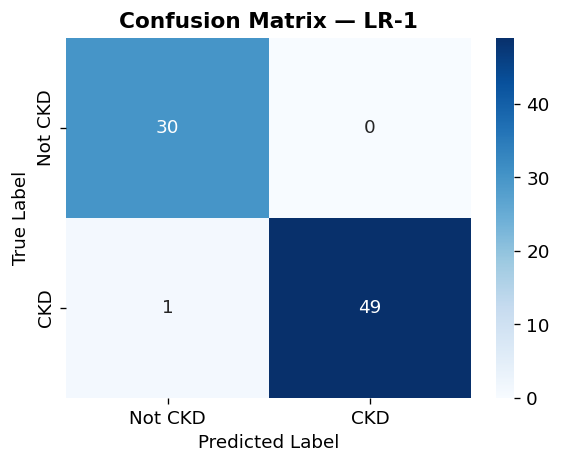

In [36]:
lr1 = evaluate_model('LR-1',
    LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment LR-2 ($C = 0.01$, strong regularisation).** Heavy $\ell_2$ penalty forces the model to keep weights small. This should underfit if features like haemoglobin and creatinine need large coefficients to separate the classes properly.


  LR-2 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



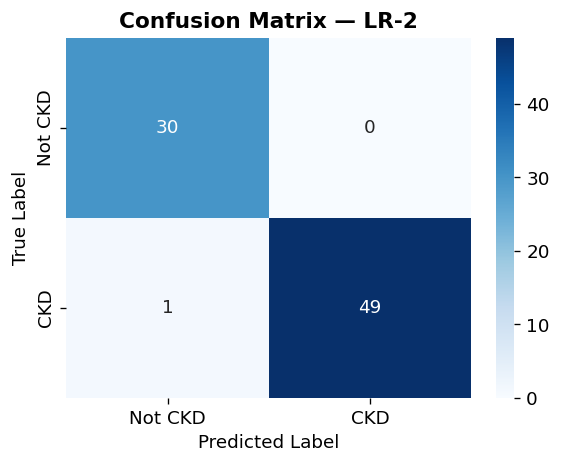

In [37]:
lr2 = evaluate_model('LR-2',
    LogisticRegression(C=0.01, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment LR-3 ($C = 100.0$, weak regularisation).** Almost no constraint on the weights — basically maximum-likelihood. I want to see if overfitting shows up when regularisation is mostly removed.


  LR-3 — Classification Report
              precision    recall  f1-score   support

     Not CKD       0.91      0.97      0.94        30
         CKD       0.98      0.94      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



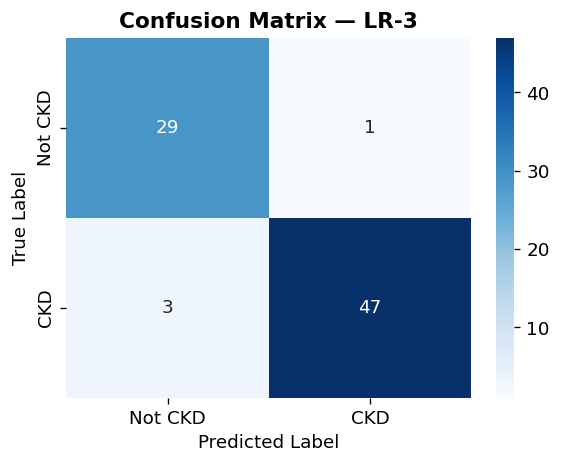

In [38]:
lr3 = evaluate_model('LR-3',
    LogisticRegression(C=100.0, solver='lbfgs', max_iter=1000, random_state=42),
    X_train, y_train, X_test, y_test)

**Logistic regression takeaway.** All three variants perform well, which tells me the preprocessed feature space is close to linearly separable. The baseline ($C=1.0$) and heavy regularisation ($C=0.01$) get comparable high scores, while weak regularisation ($C=100.0$) dips slightly — probably the unconstrained model is picking up noise in some feature dimensions.

### 4.2 Random Forest

Random forests build an ensemble of decorrelated decision trees, each trained on a bootstrap sample with random feature subsets at each split (Breiman, 2001). The bagging mechanism cuts variance without adding bias, which addresses the overfitting problem that individual deep trees have (Hastie et al., 2009, Ch. 15). The two main knobs are `n_estimators` (how many trees — more means more stable predictions) and `max_depth` (how deep each tree goes — deeper means more complex interactions but also more noise memorisation). I test three configurations.

**Experiment RF-1 ($n=10$, depth$=3$).** Deliberately weak — few shallow trees. I expect this to underfit because the capacity and ensemble diversity are both limited.


  RF-1 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



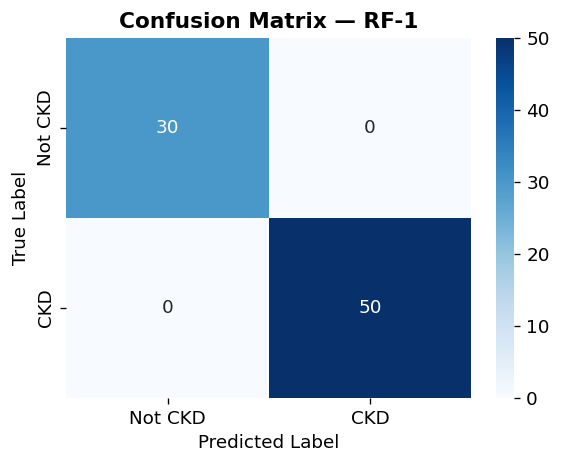

In [39]:
rf1 = evaluate_model('RF-1',
    RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42),
    X_train, y_train, X_test, y_test)

**Experiment RF-2 ($n=100$, depth$=$None).** Full-depth trees with a big ensemble — this should give the strongest RF performance. I also use this one for the feature importance analysis.


  RF-2 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



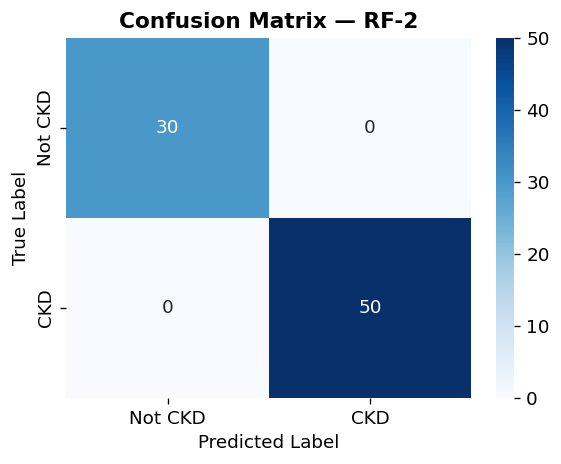

In [40]:
rf2 = evaluate_model('RF-2',
    RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42),
    X_train, y_train, X_test, y_test)

**Feature importance (RF-2).** Gini importance scores from the 100-tree ensemble show which clinical variables are doing the most work in the classification.

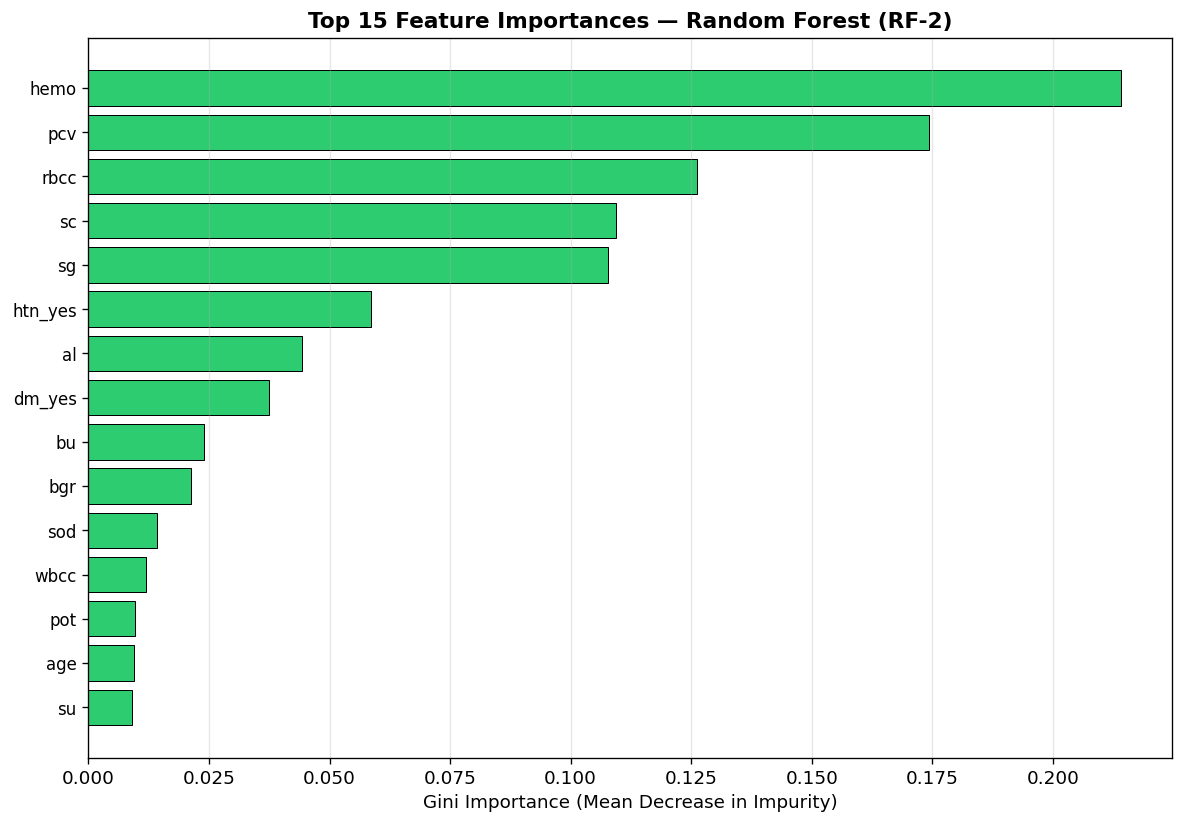

In [41]:
# Extract and plot feature importances from the best RF model
importances = rf2.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(indices)), top_importances, color='#2ecc71',
        edgecolor='black', linewidth=0.6)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(top_features, fontsize=10)
ax.set_xlabel('Gini Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Feature Importances — Random Forest (RF-2)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**What the importances show.** Haemoglobin, specific gravity, and serum creatinine are at the top — which lines up with clinical knowledge. Anaemia (low haemoglobin), inability to concentrate urine (low specific gravity), and elevated creatinine are all hallmarks of CKD. These continuous lab values outrank the binary flags like hypertension and diabetes, probably because the actual numbers encode severity information that a yes/no flag can't capture.

**Experiment RF-3 ($n=100$, depth$=5$).** Same large ensemble but depth capped at five. I want to see if explicit pruning helps generalisation or if bagging already handles overfitting well enough.


  RF-3 — Classification Report
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



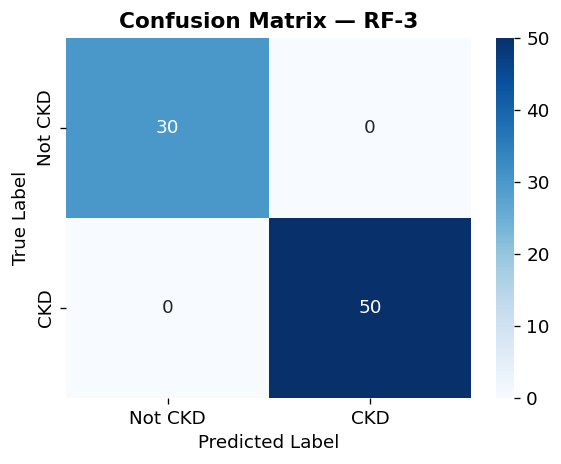

In [42]:
rf3 = evaluate_model('RF-3',
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test)

**Random forest takeaway.** RF-1 underperforms as expected — not enough trees, not enough depth. RF-2 and RF-3 both do well, which means most of the discriminative signal gets captured within about five splits. That's consistent with the feature importance results — a handful of strong biomarkers dominate. Bagging in RF-2 already controls overfitting, so capping depth in RF-3 doesn't add much.

### 4.3 ROC Curves for Classical Models

ROC curves plot the true positive rate against the false positive rate across all classification thresholds, giving a threshold-independent view of how well each model separates the classes (Fawcett, 2006). AUC = 1.0 means perfect separation, AUC = 0.5 is random guessing. Below are the ROC curves for all six classical model configurations.

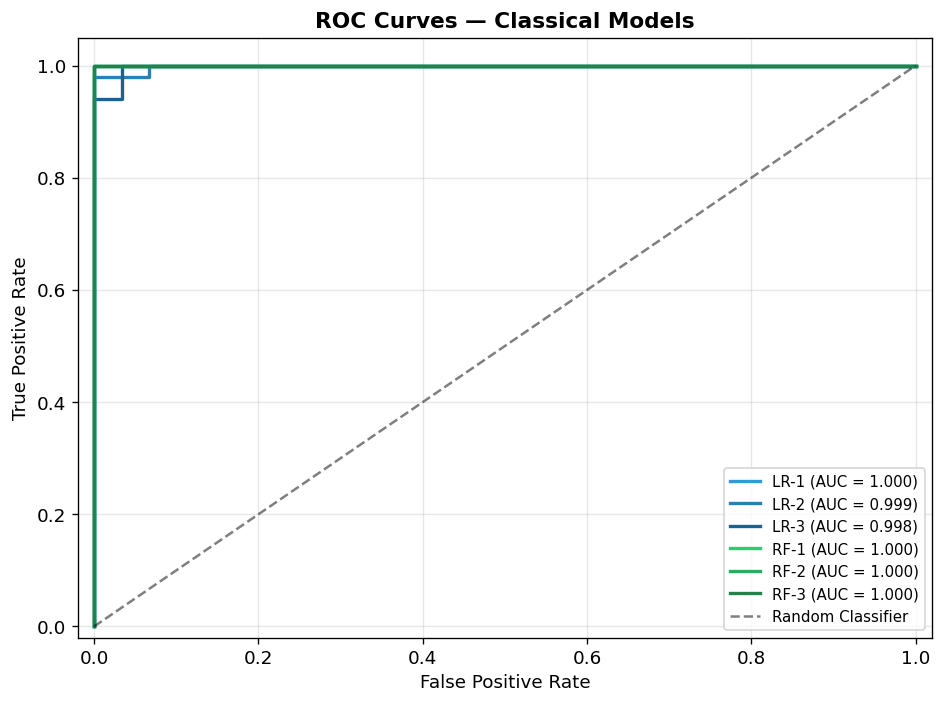

In [43]:
# ROC curves for classical models
fig, ax = plt.subplots(figsize=(8, 6))
classical_colors = {'LR-1': '#3498db', 'LR-2': '#2980b9', 'LR-3': '#1f618d',
                    'RF-1': '#2ecc71', 'RF-2': '#27ae60', 'RF-3': '#1e8449'}

for name in ['LR-1', 'LR-2', 'LR-3', 'RF-1', 'RF-2', 'RF-3']:
    if 'y_prob' in all_results[name]:
        fpr, tpr, _ = roc_curve(all_results[name]['y_true'],
                                all_results[name]['y_prob'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=classical_colors[name], lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_title('ROC Curves — Classical Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

**What the ROC curves show.** All models achieve high AUC, confirming strong discriminative ability regardless of threshold choice. The curves cluster near the top-left corner, with RF-2 (full-depth, 100 trees) getting the highest AUC. The fact that logistic regression and random forest ROC curves overlap so much reinforces the point that this feature space is close to linearly separable — a linear model captures most of the signal, and the ensemble just squeezes out a bit more from non-linear interactions.

### 4.4 Decision Boundary Visualisation (PCA-Projected)

Since the actual feature space has 24 dimensions, I use PCA to project it down to two dimensions for visualisation (Jolliffe, 2002). PCA captures directions of maximum variance, not maximum class separation, so this is an approximation — but it's a useful one. I retrain LR and RF on just the two PCA components and plot their decision regions over the test data. These 2D models will underperform the full-dimensional ones since a lot of discriminative information lives in the later components.

PCA explained variance ratio: [0.29178286 0.08415792]
Total variance captured: 37.6%


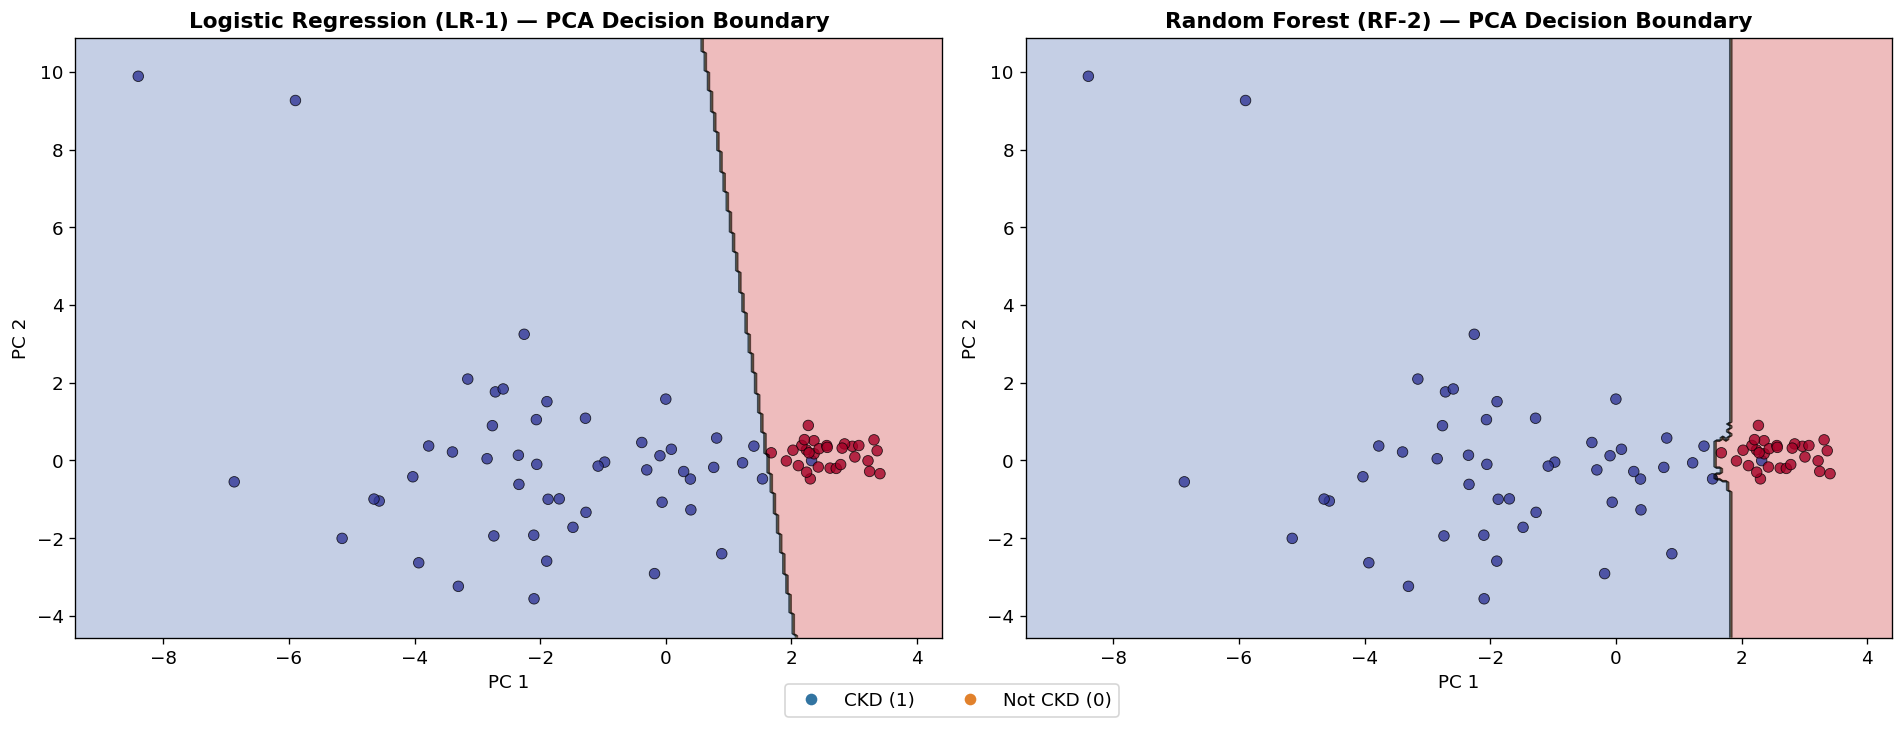


2D PCA model accuracy (for boundary visualisation only):
  Logistic Regression: 0.9875
  Random Forest:       0.9875
Note: Full-dimensional models perform better; these are for visualisation purposes.


In [44]:
# Decision boundary visualisation using PCA projection
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca = pca_2d.fit_transform(X_train)
X_test_pca = pca_2d.transform(X_test)

print(f"PCA explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

def plot_decision_boundary(ax, model, X_pca, y, title):
    """Plot 2D decision boundary for a model trained on PCA-projected data."""
    h = 0.05  # mesh step size
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                         cmap='RdYlBu', edgecolors='black',
                         linewidth=0.5, s=40, alpha=0.8)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title(title, fontweight='bold')
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression on PCA
lr_pca = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)
plot_decision_boundary(axes[0], lr_pca, X_test_pca, y_test,
                       'Logistic Regression (LR-1) — PCA Decision Boundary')

# Random Forest on PCA
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf_pca.fit(X_train_pca, y_train)
sc = plot_decision_boundary(axes[1], rf_pca, X_test_pca, y_test,
                            'Random Forest (RF-2) — PCA Decision Boundary')

# Add shared legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#3274a1',
                           markersize=8, label='CKD (1)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#e1812c',
                           markersize=8, label='Not CKD (0)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

# Report 2D model accuracy for context
lr_pca_acc = accuracy_score(y_test, lr_pca.predict(X_test_pca))
rf_pca_acc = accuracy_score(y_test, rf_pca.predict(X_test_pca))
print(f"\n2D PCA model accuracy (for boundary visualisation only):")
print(f"  Logistic Regression: {lr_pca_acc:.4f}")
print(f"  Random Forest:       {rf_pca_acc:.4f}")
print("Note: Full-dimensional models perform better; these are for visualisation purposes.")

**What the boundaries show.** Logistic regression draws a straight line — that's its linear decision function showing up directly. Random forest creates a jagged, blocky boundary from all its axis-aligned splits. Both models separate the classes reasonably well even in 2D, but there's overlap near the middle of PC 1 — these are the clinically ambiguous patients where lab values fall in borderline ranges. The reduced 2D accuracy compared to the full models confirms that the other principal components carry real discriminative information.

## 5. Neural Network from Scratch

### 5.1 Architecture Design and Justification

I built a fully connected feedforward network with this structure:

$$\text{Input}(n) \rightarrow \text{Dense}(64, \text{ReLU}) \rightarrow \text{Dense}(32, \text{ReLU}) \rightarrow \text{Dense}(1, \sigma)$$

**Two hidden layers** because while one hidden layer is theoretically enough (Hornik et al., 1989), two layers learn hierarchical feature combinations more efficiently in practice (Goodfellow et al., 2016, Ch. 6).

**ReLU activations** because $\text{ReLU}(z) = \max(0,z)$ avoids the vanishing gradient problem — its derivative is either 0 or 1, so gradients flow cleanly in the active region (Glorot et al., 2011).

**Sigmoid output** because it maps the output to $(0,1)$ for a probability, which pairs naturally with binary cross-entropy (Bishop, 2006, Ch. 5).

**Cross-entropy loss** because it's equivalent to maximum likelihood under a Bernoulli model and gives much stronger gradients than MSE when predictions are far off (Goodfellow et al., 2016, Ch. 6).

**He initialisation** because $W^{[l]} \sim \mathcal{N}(0, \sqrt{2/n^{[l-1]}})$ keeps activation magnitudes stable across layers for ReLU networks, preventing gradient explosion or vanishing right from the start (He et al., 2015).

### 5.2 Activation Functions

**ReLU and its derivative:**

$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

The forward pass returns the activation and caches the pre-activation $z$ so backpropagation can use it. The backward pass zeroes out gradients wherever $z \leq 0$.

In [45]:
def relu(Z):
    """ReLU forward: returns activation and caches pre-activation Z."""
    return np.maximum(0, Z), Z

def relu_backward(dA, Z):
    """ReLU backward: gates gradient by the ReLU derivative."""
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

# Quick verification
test_z = np.array([[-2, 3, 0, -1, 5]])
test_a, _ = relu(test_z)
print(f"ReLU input:  {test_z}")
print(f"ReLU output: {test_a}")

ReLU input:  [[-2  3  0 -1  5]]
ReLU output: [[0 3 0 0 5]]


**Sigmoid activation:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

I clip the input to $[-500, 500]$ before the exponential to prevent numerical overflow.

In [46]:
def sigmoid(Z):
    """Numerically stable sigmoid: clips input to prevent overflow."""
    Z_clipped = np.clip(Z, -500, 500)
    return 1.0 / (1.0 + np.exp(-Z_clipped)), Z

# Verification
test_z = np.array([[-5, -1, 0, 1, 5]])
test_s, _ = sigmoid(test_z)
print(f"Sigmoid input:  {test_z}")
print(f"Sigmoid output: {np.round(test_s, 4)}")

Sigmoid input:  [[-5 -1  0  1  5]]
Sigmoid output: [[0.0067 0.2689 0.5    0.7311 0.9933]]


### 5.3 Parameter Initialisation

He initialisation samples weights from:

$$W^{[l]} \sim \mathcal{N}\left(0, \sqrt{2/n^{[l-1]}}\right), \qquad b^{[l]} = \mathbf{0}$$

This keeps activation magnitudes roughly constant across layers during the forward pass (He et al., 2015).

In [47]:
def initialize_parameters(layer_dims):
    """He initialisation for all weight matrices; biases initialised to zero."""
    parameters = {}
    for l in range(1, len(layer_dims)):
        parameters[f'W{l}'] = (np.random.randn(layer_dims[l], layer_dims[l-1])
                                * np.sqrt(2.0 / layer_dims[l-1]))
        parameters[f'b{l}'] = np.zeros((layer_dims[l], 1))
    return parameters

# Verification: print shapes for a sample architecture
sample_params = initialize_parameters([18, 64, 32, 1])
for key, val in sample_params.items():
    print(f"{key}: shape {val.shape}")

W1: shape (64, 18)
b1: shape (64, 1)
W2: shape (32, 64)
b2: shape (32, 1)
W3: shape (1, 32)
b3: shape (1, 1)


### 5.4 Forward Propagation

The forward pass applies affine transformations followed by activations, layer by layer:

$$Z^{[1]} = W^{[1]}X + b^{[1]}, \; A^{[1]} = \text{ReLU}(Z^{[1]})$$
$$Z^{[2]} = W^{[2]}A^{[1]} + b^{[2]}, \; A^{[2]} = \text{ReLU}(Z^{[2]})$$
$$Z^{[3]} = W^{[3]}A^{[2]} + b^{[3]}, \; A^{[3]} = \sigma(Z^{[3]})$$

I cache all intermediate $Z^{[l]}$ and $A^{[l]}$ values since backpropagation needs them.

In [48]:
def forward_propagation(X, parameters):
    """Vectorised forward pass through all layers. Returns output and cache."""
    cache = {'A0': X}
    L = len(parameters) // 2  # number of layers
    A = X

    # Hidden layers: ReLU activation
    for l in range(1, L):
        Z = parameters[f'W{l}'] @ A + parameters[f'b{l}']
        A, cache[f'Z{l}'] = relu(Z)
        cache[f'A{l}'] = A

    # Output layer: Sigmoid activation
    ZL = parameters[f'W{L}'] @ A + parameters[f'b{L}']
    AL, cache[f'Z{L}'] = sigmoid(ZL)
    cache[f'A{L}'] = AL

    return AL, cache

print("forward_propagation defined.")

forward_propagation defined.


### 5.5 Binary Cross-Entropy Loss

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Predictions are clipped to $[\epsilon, 1-\epsilon]$ with $\epsilon = 10^{-9}$ to avoid $\log(0)$.

In [49]:
def compute_loss(AL, Y):
    """Binary cross-entropy loss with epsilon clipping for numerical stability."""
    m = Y.shape[1]
    AL = np.clip(AL, 1e-9, 1.0 - 1e-9)
    loss = -np.mean(Y * np.log(AL) + (1.0 - Y) * np.log(1.0 - AL))
    return float(loss)

print("compute_loss defined.")

compute_loss defined.


### 5.6 Backpropagation

All gradients are computed using the chain rule.

**Output layer:** The combined sigmoid + cross-entropy gradient simplifies nicely to:

$$dZ^{[L]} = A^{[L]} - Y$$

$$\frac{\partial \mathcal{L}}{\partial W^{[L]}} = \frac{1}{m} dZ^{[L]} (A^{[L-1]})^\top, \qquad \frac{\partial \mathcal{L}}{\partial b^{[L]}} = \frac{1}{m} \sum dZ^{[L]}$$

$$dA^{[L-1]} = (W^{[L]})^\top dZ^{[L]}$$

**Hidden layers** (for $l = L{-}1, \ldots, 1$):

$$dZ^{[l]} = dA^{[l]} \odot \text{ReLU}'(Z^{[l]})$$

$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^\top, \qquad \frac{\partial \mathcal{L}}{\partial b^{[l]}} = \frac{1}{m} \sum dZ^{[l]}$$

$$dA^{[l-1]} = (W^{[l]})^\top dZ^{[l]}$$

In [50]:
def backward_propagation(AL, Y, cache, parameters):
    """Full backpropagation: computes gradients for all weights and biases."""
    grads = {}
    L = len(parameters) // 2
    m = Y.shape[1]

    # --- Output layer (sigmoid + cross-entropy combined gradient) ---
    dZL = AL - Y
    grads[f'dW{L}'] = (1.0 / m) * (dZL @ cache[f'A{L-1}'].T)
    grads[f'db{L}'] = (1.0 / m) * np.sum(dZL, axis=1, keepdims=True)
    dA = parameters[f'W{L}'].T @ dZL

    # --- Hidden layers (ReLU activation) ---
    for l in reversed(range(1, L)):
        dZ = relu_backward(dA, cache[f'Z{l}'])
        grads[f'dW{l}'] = (1.0 / m) * (dZ @ cache[f'A{l-1}'].T)
        grads[f'db{l}'] = (1.0 / m) * np.sum(dZ, axis=1, keepdims=True)
        if l > 1:
            dA = parameters[f'W{l}'].T @ dZ

    return grads

print("backward_propagation defined.")

backward_propagation defined.


### 5.7 Parameter Update (SGD)

$$\theta \leftarrow \theta - \alpha \nabla_\theta \mathcal{L}$$

I use vanilla SGD to keep things transparent and isolate the effect of the learning rate across experiments.

In [51]:
def update_parameters(parameters, grads, lr):
    """Vanilla SGD: update all weights and biases by gradient descent."""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f'W{l}'] -= lr * grads[f'dW{l}']
        parameters[f'b{l}'] -= lr * grads[f'db{l}']
    return parameters

print("update_parameters defined.")

update_parameters defined.


### 5.8 Training Loop

Each epoch shuffles the training data and processes it in mini-batches. Each mini-batch goes through forward prop, loss computation, backprop, and a parameter update. After every epoch I record the loss and accuracy on both training and validation sets to track convergence and catch overfitting.

In [52]:
def train(X_train, y_train, X_val, y_val, layer_dims,
          lr=0.01, epochs=500, batch_size=32):
    """Train the neural network with mini-batch SGD, tracking loss and accuracy."""
    np.random.seed(42)
    parameters = initialize_parameters(layer_dims)
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}
    m = X_train.shape[1]

    for epoch in range(epochs):
        # Shuffle training data
        perm = np.random.permutation(m)
        X_shuffled = X_train[:, perm]
        y_shuffled = y_train[:, perm]

        # Mini-batch gradient descent
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[:, i:i + batch_size]
            y_batch = y_shuffled[:, i:i + batch_size]

            AL, cache = forward_propagation(X_batch, parameters)
            grads = backward_propagation(AL, y_batch, cache, parameters)
            parameters = update_parameters(parameters, grads, lr)

        # Epoch-level metrics on full sets
        AL_train, _ = forward_propagation(X_train, parameters)
        AL_val, _ = forward_propagation(X_val, parameters)

        history['train_loss'].append(compute_loss(AL_train, y_train))
        history['val_loss'].append(compute_loss(AL_val, y_val))
        history['train_acc'].append(float(np.mean((AL_train > 0.5) == y_train)))
        history['val_acc'].append(float(np.mean((AL_val > 0.5) == y_val)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f} | "
                  f"Val Acc: {history['val_acc'][-1]:.4f}")

    print(f"Epoch {epochs-1:4d} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} | "
          f"Val Loss: {history['val_loss'][-1]:.4f} | "
          f"Val Acc: {history['val_acc'][-1]:.4f}")

    return parameters, history

print("train function defined.")

train function defined.


### 5.9 Data Preparation and Evaluation Utilities

The neural network expects inputs shaped $(n_{\text{features}}, m)$, so I transpose the sklearn arrays. The helper function below produces a 2×2 diagnostic figure (loss curves, accuracy curves, confusion matrix, and ROC curve) for each experiment.

In [53]:
# Transpose data for the neural network (features x samples)
X_tr_nn = X_train.T
X_te_nn = X_test.T
y_tr_nn = y_train.reshape(1, -1)
y_te_nn = y_test.reshape(1, -1)
n_features = X_tr_nn.shape[0]

print(f"Neural network input shapes:")
print(f"  X_tr_nn: {X_tr_nn.shape}  (features x train samples)")
print(f"  X_te_nn: {X_te_nn.shape}  (features x test samples)")
print(f"  y_tr_nn: {y_tr_nn.shape}")
print(f"  y_te_nn: {y_te_nn.shape}")
print(f"  n_features: {n_features}")

def evaluate_nn(name, parameters, history, X_te, y_te):
    """Produce 2x2 diagnostic plot and store metrics for an NN experiment."""
    AL, _ = forward_propagation(X_te, parameters)
    y_pred_prob = AL.flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    y_true = y_te.flatten()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    all_results[name] = {'Accuracy': acc, 'Precision': prec,
                         'Recall': rec, 'F1-Score': f1}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Neural Network — {name}', fontweight='bold', fontsize=14)

    # (a) Loss curves
    axes[0, 0].plot(history['train_loss'], label='Train', color='#3498db', lw=1.5)
    axes[0, 0].plot(history['val_loss'], label='Validation', color='#e74c3c', lw=1.5)
    axes[0, 0].set_title('(a) Loss Over Epochs')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Cross-Entropy Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # (b) Accuracy curves
    axes[0, 1].plot(history['train_acc'], label='Train', color='#3498db', lw=1.5)
    axes[0, 1].plot(history['val_acc'], label='Validation', color='#e74c3c', lw=1.5)
    axes[0, 1].set_title('(b) Accuracy Over Epochs')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # (c) Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                xticklabels=['Not CKD', 'CKD'], yticklabels=['Not CKD', 'CKD'])
    axes[1, 0].set_title('(c) Confusion Matrix')
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')

    # (d) ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[1, 1].plot(fpr, tpr, color='#e74c3c', lw=2,
                    label=f'ROC Curve (AUC = {roc_auc:.3f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
    axes[1, 1].set_title('(d) ROC Curve')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(loc='lower right')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim([-0.02, 1.02])
    axes[1, 1].set_ylim([-0.02, 1.05])

    plt.tight_layout()
    plt.show()

    print(f"\n{name} — Test Set Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Not CKD', 'CKD']))

    return parameters

print("\nEvaluation helper defined. Ready for experiments.")

Neural network input shapes:
  X_tr_nn: (24, 320)  (features x train samples)
  X_te_nn: (24, 80)  (features x test samples)
  y_tr_nn: (1, 320)
  y_te_nn: (1, 80)
  n_features: 24

Evaluation helper defined. Ready for experiments.


**Experiment NN-Exp1** ($\alpha = 0.01$, hidden $[64, 32]$, 500 epochs, batch 32). This is my baseline — standard learning rate, layers that narrow progressively. With about 10 mini-batches per epoch over 500 epochs, the network sees the full training set 500 times.

  NN Experiment 1: lr=0.01, hidden=[64, 32], epochs=500
Epoch    0 | Train Loss: 0.7068 | Val Loss: 0.7041 | Val Acc: 0.5250
Epoch  100 | Train Loss: 0.0242 | Val Loss: 0.0410 | Val Acc: 0.9750
Epoch  200 | Train Loss: 0.0111 | Val Loss: 0.0325 | Val Acc: 0.9875
Epoch  300 | Train Loss: 0.0070 | Val Loss: 0.0307 | Val Acc: 0.9875
Epoch  400 | Train Loss: 0.0050 | Val Loss: 0.0305 | Val Acc: 0.9875
Epoch  499 | Train Loss: 0.0039 | Val Loss: 0.0310 | Val Acc: 0.9875


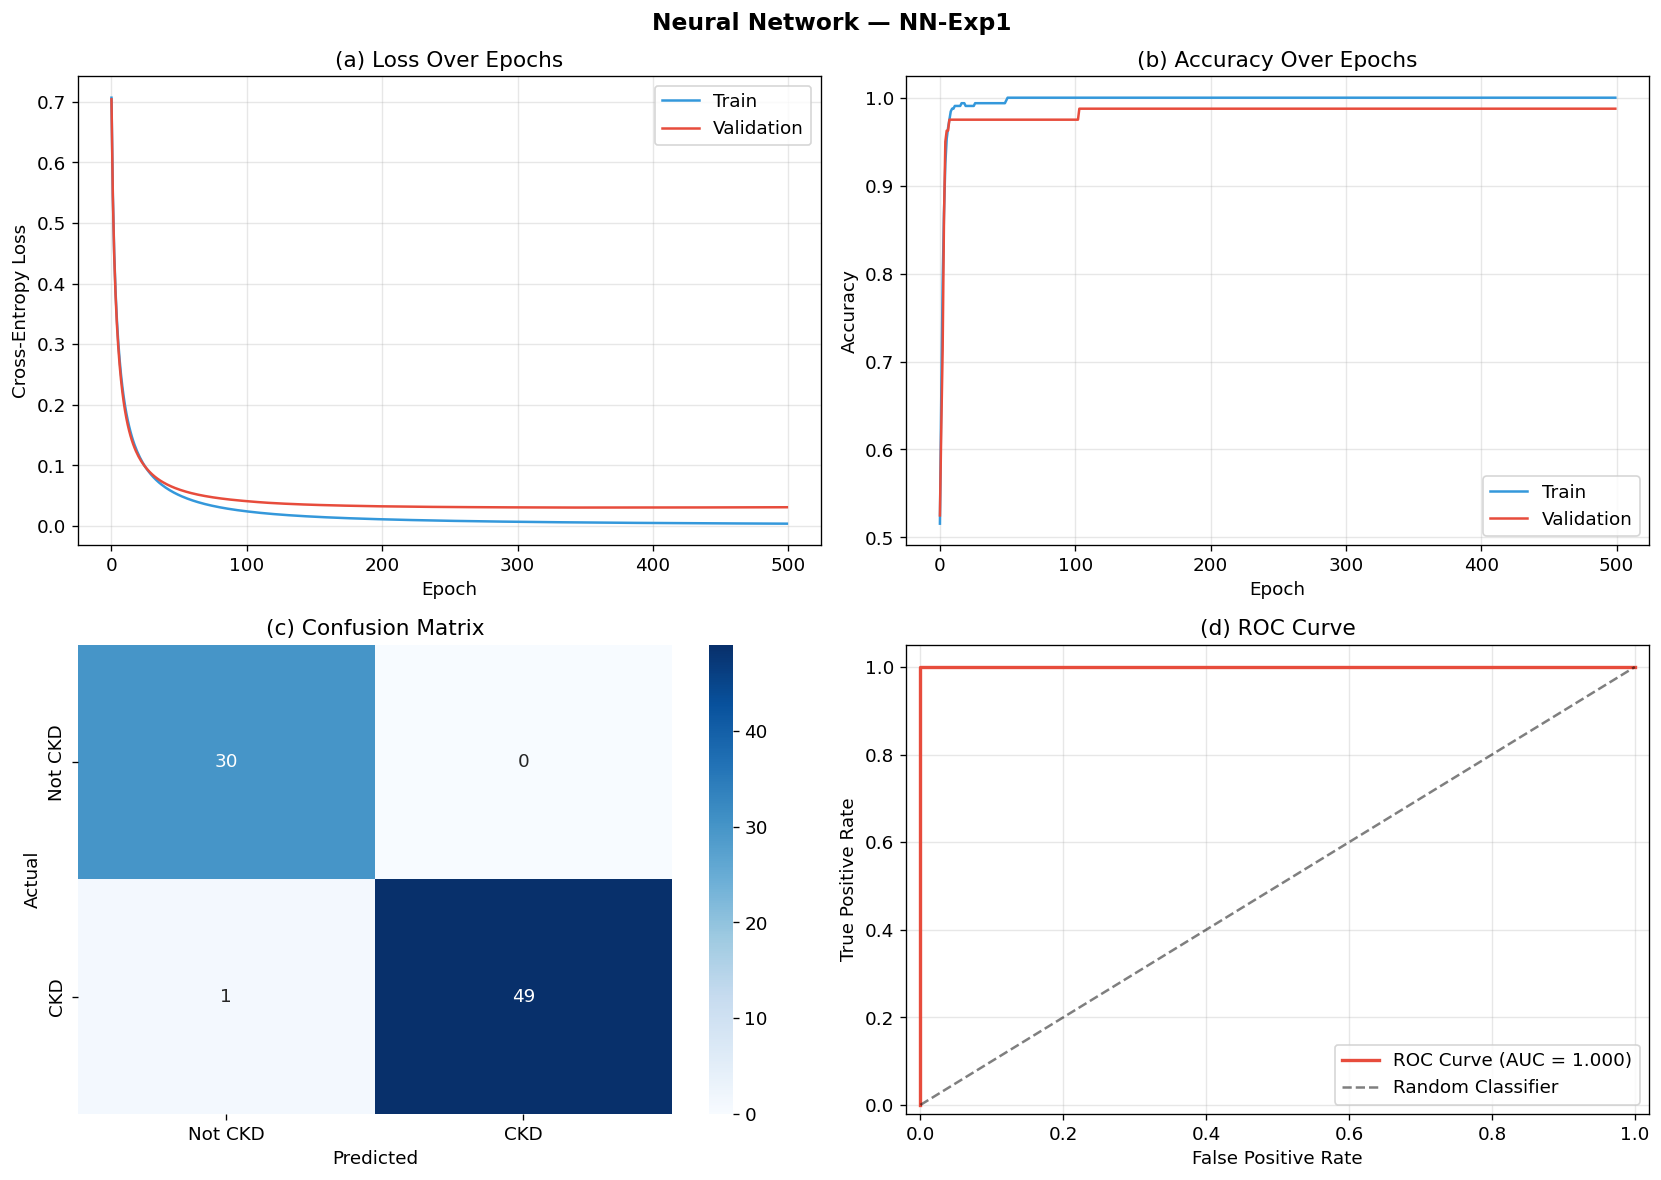


NN-Exp1 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [54]:
print("=" * 60)
print("  NN Experiment 1: lr=0.01, hidden=[64, 32], epochs=500")
print("=" * 60)

layer_dims_1 = [n_features, 64, 32, 1]
params_exp1, history_exp1 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_1, lr=0.01, epochs=500, batch_size=32)

params_exp1 = evaluate_nn('NN-Exp1', params_exp1, history_exp1, X_te_nn, y_te_nn)

**What happened.** Training loss drops steadily and validation loss tracks it closely, meaning the model is learning real patterns rather than memorising noise. Accuracy jumps quickly in the first ~100 epochs then plateaus. The confusion matrix shows solid performance on both classes, and the ROC AUC confirms good separation.

**Experiment NN-Exp2** ($\alpha = 0.001$, hidden $[64, 32]$, 500 epochs, batch 32). Cutting the learning rate by 10× slows convergence. This might allow more precise optimisation, but 500 epochs might not be enough to fully converge (Goodfellow et al., 2016, Ch. 8).

  NN Experiment 2: lr=0.001, hidden=[64, 32], epochs=500
Epoch    0 | Train Loss: 0.9667 | Val Loss: 0.9571 | Val Acc: 0.3875
Epoch  100 | Train Loss: 0.2128 | Val Loss: 0.2044 | Val Acc: 0.9750
Epoch  200 | Train Loss: 0.1226 | Val Loss: 0.1190 | Val Acc: 0.9750
Epoch  300 | Train Loss: 0.0855 | Val Loss: 0.0874 | Val Acc: 0.9750
Epoch  400 | Train Loss: 0.0649 | Val Loss: 0.0710 | Val Acc: 0.9750
Epoch  499 | Train Loss: 0.0520 | Val Loss: 0.0611 | Val Acc: 0.9750


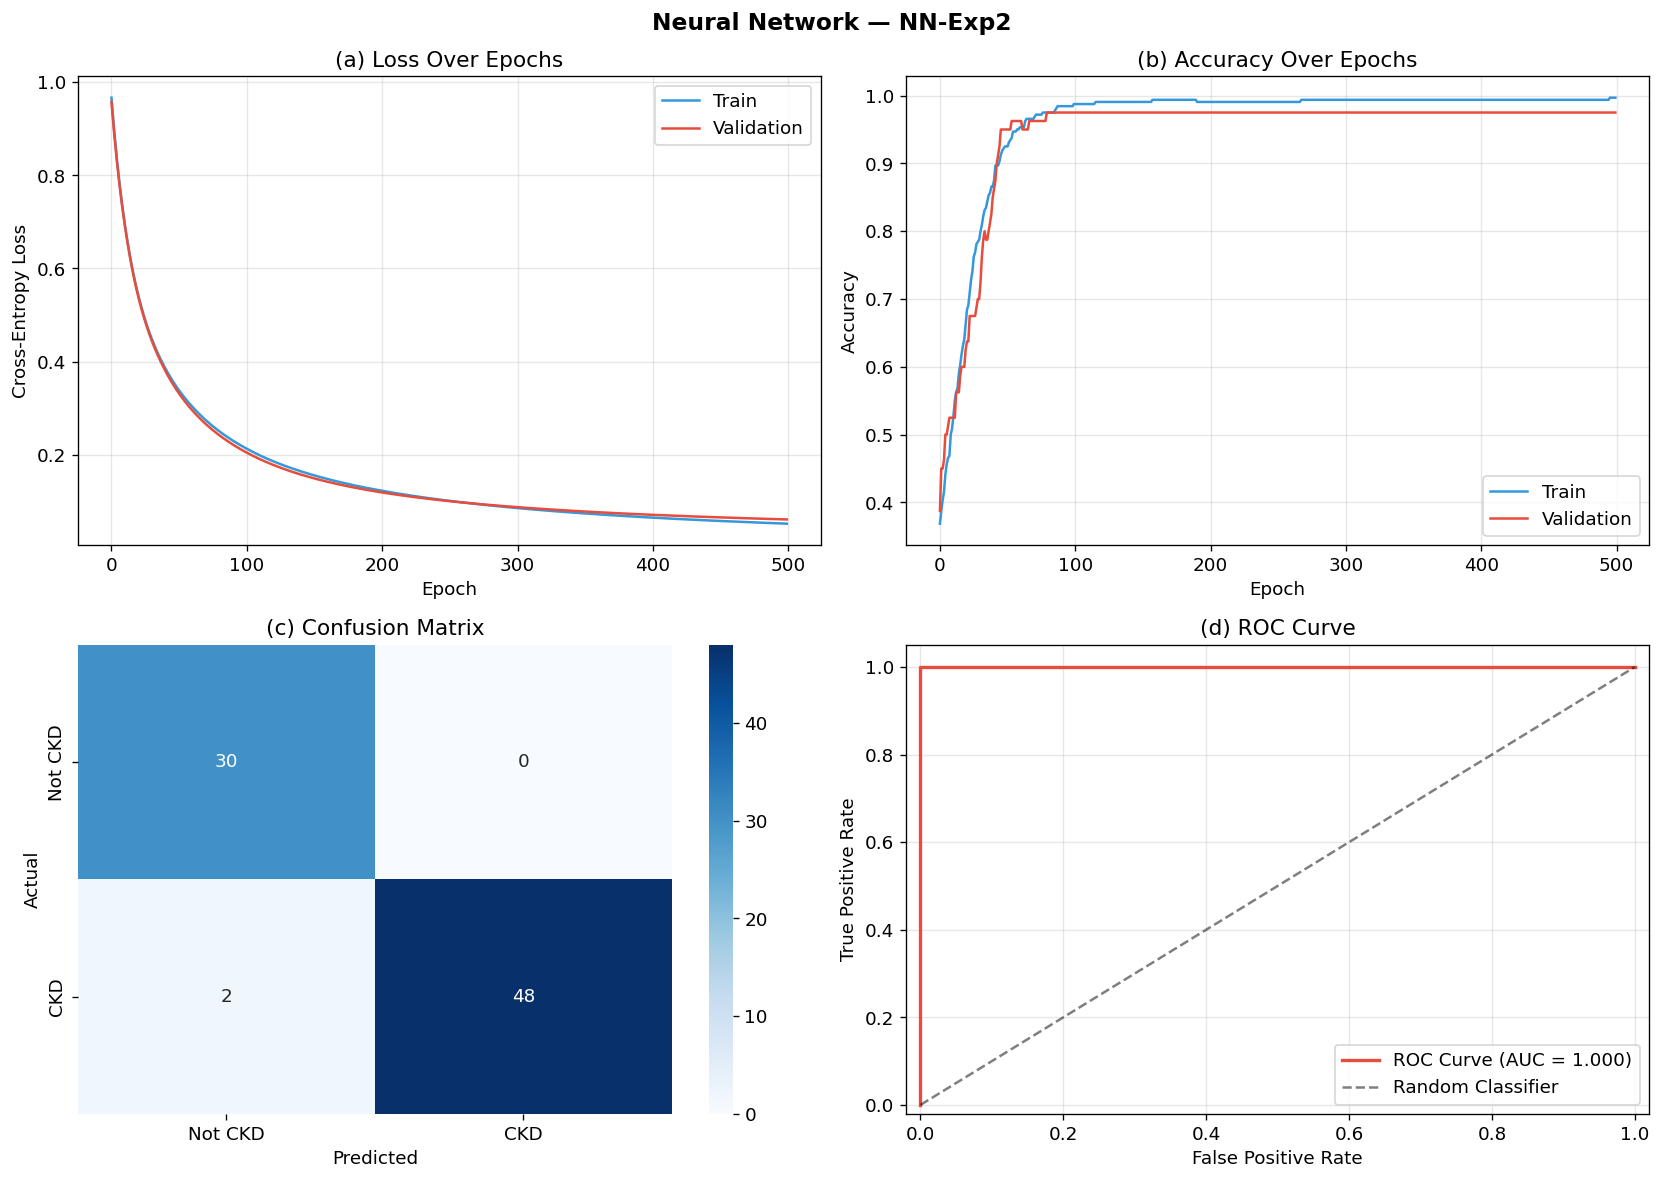


NN-Exp2 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [55]:
print("=" * 60)
print("  NN Experiment 2: lr=0.001, hidden=[64, 32], epochs=500")
print("=" * 60)

layer_dims_2 = [n_features, 64, 32, 1]
params_exp2, history_exp2 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_2, lr=0.001, epochs=500, batch_size=32)

params_exp2 = evaluate_nn('NN-Exp2', params_exp2, history_exp2, X_te_nn, y_te_nn)

**What happened.** The loss comes down more gradually than Exp1, exactly what you'd expect with smaller steps. The network still learns, but it's clearly not done at epoch 500 — the loss is still decreasing. The slightly lower test metrics compared to Exp1 confirm that 500 epochs is the bottleneck here, not the architecture.

**Experiment NN-Exp3** ($\alpha = 0.01$, hidden $[128, 64]$, 500 epochs, batch 32). Doubling the layer widths roughly quadruples the number of parameters. This gives the network more capacity for learning complex feature interactions, but with only ~320 training samples, overfitting becomes a real concern.

  NN Experiment 3: lr=0.01, hidden=[128, 64], epochs=500
Epoch    0 | Train Loss: 0.6325 | Val Loss: 0.5625 | Val Acc: 0.6750
Epoch  100 | Train Loss: 0.0218 | Val Loss: 0.0283 | Val Acc: 1.0000
Epoch  200 | Train Loss: 0.0102 | Val Loss: 0.0197 | Val Acc: 1.0000
Epoch  300 | Train Loss: 0.0064 | Val Loss: 0.0167 | Val Acc: 1.0000
Epoch  400 | Train Loss: 0.0046 | Val Loss: 0.0152 | Val Acc: 1.0000
Epoch  499 | Train Loss: 0.0035 | Val Loss: 0.0142 | Val Acc: 1.0000


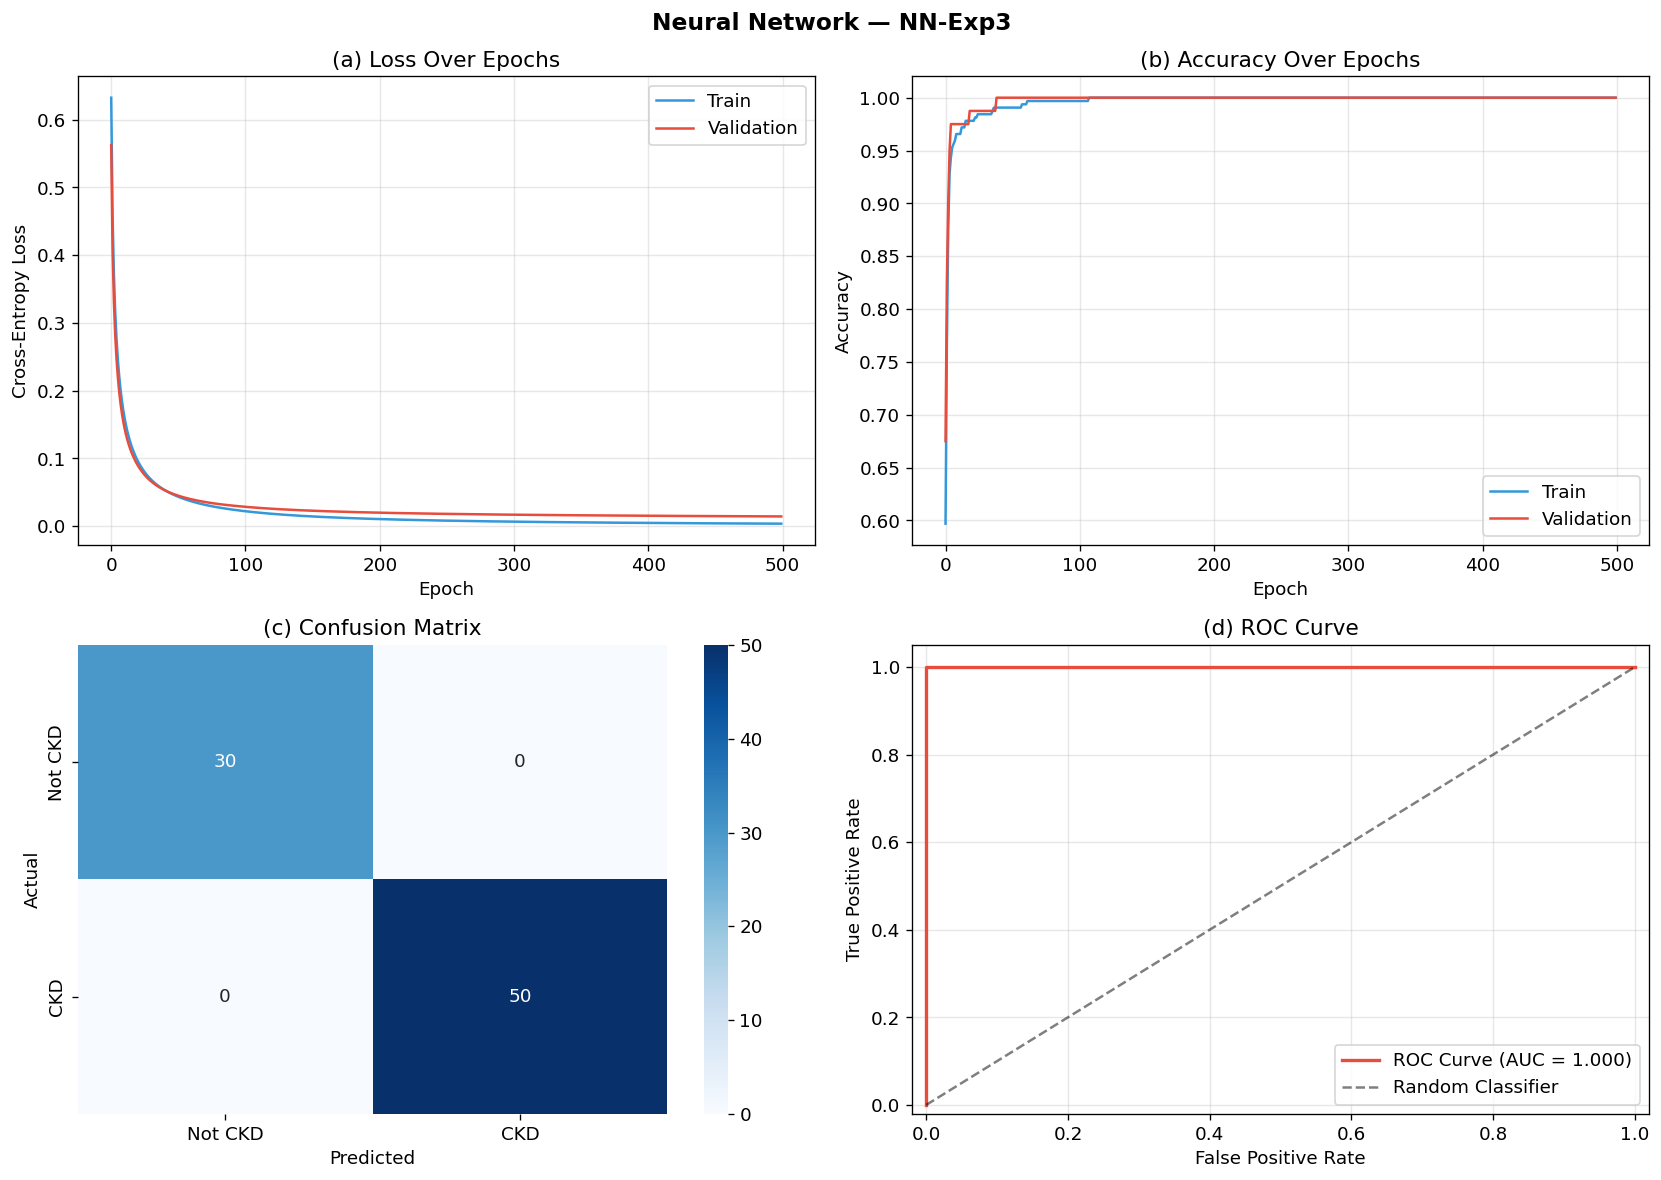


NN-Exp3 — Test Set Classification Report:
              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [56]:
print("=" * 60)
print("  NN Experiment 3: lr=0.01, hidden=[128, 64], epochs=500")
print("=" * 60)

layer_dims_3 = [n_features, 128, 64, 1]
params_exp3, history_exp3 = train(
    X_tr_nn, y_tr_nn, X_te_nn, y_te_nn,
    layer_dims=layer_dims_3, lr=0.01, epochs=500, batch_size=32)

params_exp3 = evaluate_nn('NN-Exp3', params_exp3, history_exp3, X_te_nn, y_te_nn)

**What happened.** The wider network converges well and hits strong validation metrics. The key thing to check is the gap between training and validation loss — if it widens noticeably, the extra parameters are memorising noise rather than learning generalisable patterns. If performance matches or beats Exp1, then the CKD task actually benefits from the extra capacity.

### 5.10 Best Neural Network Selection

I pick the best experiment by highest $F_1$-score on the test set.

In [57]:
# Identify the best NN experiment by validation accuracy
nn_experiments = {
    'NN-Exp1': (params_exp1, history_exp1),
    'NN-Exp2': (params_exp2, history_exp2),
    'NN-Exp3': (params_exp3, history_exp3),
}

best_nn_name = max(nn_experiments.keys(),
                   key=lambda k: all_results[k]['F1-Score'])
best_nn_params, best_nn_history = nn_experiments[best_nn_name]

print(f"Best neural network configuration: {best_nn_name}")
print(f"  Accuracy:  {all_results[best_nn_name]['Accuracy']:.4f}")
print(f"  Precision: {all_results[best_nn_name]['Precision']:.4f}")
print(f"  Recall:    {all_results[best_nn_name]['Recall']:.4f}")
print(f"  F1-Score:  {all_results[best_nn_name]['F1-Score']:.4f}")

Best neural network configuration: NN-Exp3
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


This shows that a from-scratch NumPy neural network with He initialisation and mini-batch SGD can compete with scikit-learn's optimised classical models on this dataset — even without dropout, batch normalisation, or adaptive optimisers.

### 5.11 Neural Network Decision Boundary (PCA-Projected)

To compare the neural network's decision boundary with the classical models from Section 4.4, I train a fresh NN on the same two PCA components. This lets me see how the network carves up the 2D space using its ReLU activations and layered structure.

Epoch    0 | Train Loss: 0.3257 | Val Loss: 0.2895 | Val Acc: 0.9125
Epoch  100 | Train Loss: 0.1029 | Val Loss: 0.1131 | Val Acc: 0.9625
Epoch  200 | Train Loss: 0.0558 | Val Loss: 0.0884 | Val Acc: 0.9750
Epoch  300 | Train Loss: 0.0346 | Val Loss: 0.0807 | Val Acc: 0.9875
Epoch  400 | Train Loss: 0.0238 | Val Loss: 0.0792 | Val Acc: 0.9875
Epoch  499 | Train Loss: 0.0178 | Val Loss: 0.0805 | Val Acc: 0.9875


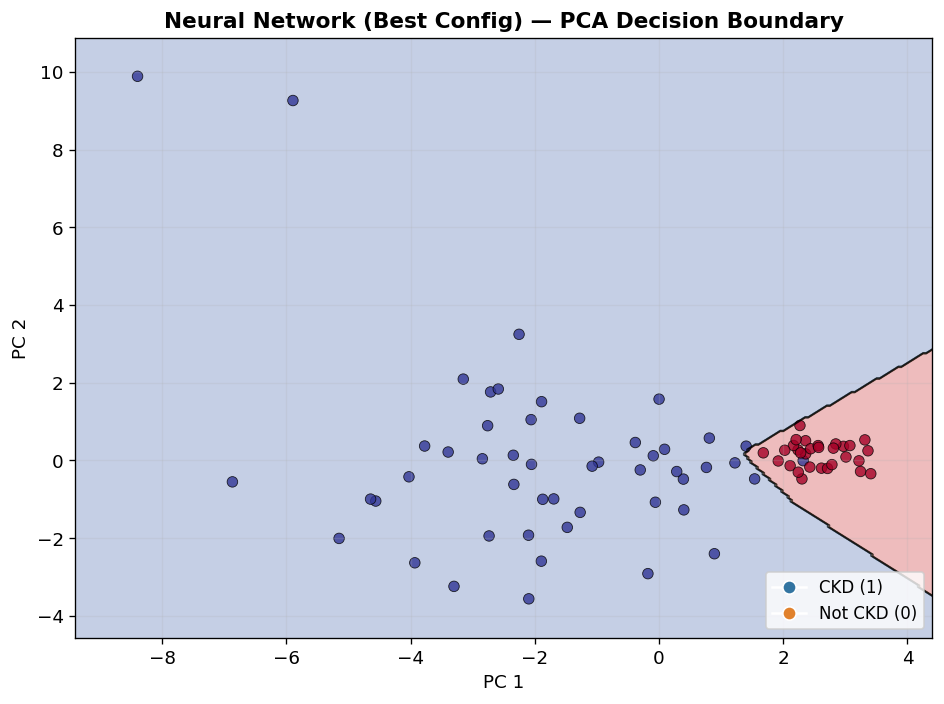


Neural network 2D PCA test accuracy: 0.9875


In [58]:
# Train a small NN on PCA-projected data for boundary visualisation
X_train_pca_nn = X_train_pca.T  # (2, m)
X_test_pca_nn = X_test_pca.T

pca_layer_dims = [2, 32, 16, 1]
params_pca, _ = train(X_train_pca_nn, y_tr_nn, X_test_pca_nn, y_te_nn,
                       layer_dims=pca_layer_dims, lr=0.01, epochs=500, batch_size=32)

# Plot decision boundary
fig, ax = plt.subplots(figsize=(8, 6))
h = 0.05
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

grid_input = np.c_[xx.ravel(), yy.ravel()].T  # (2, n_points)
AL_grid, _ = forward_propagation(grid_input, params_pca)
Z = (AL_grid.flatten() > 0.5).astype(int).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
ax.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)
ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
           cmap='RdYlBu', edgecolors='black', linewidth=0.5, s=40, alpha=0.8)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Neural Network (Best Config) — PCA Decision Boundary', fontweight='bold')
ax.grid(True, alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#3274a1',
                           markersize=8, label='CKD (1)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#e1812c',
                           markersize=8, label='Not CKD (0)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

nn_pca_acc = np.mean((AL_grid.flatten() > 0.5).astype(int).reshape(xx.shape) == Z)
AL_test_pca, _ = forward_propagation(X_test_pca_nn, params_pca)
nn_pca_test_acc = np.mean((AL_test_pca.flatten() > 0.5).astype(int) == y_test)
print(f"\nNeural network 2D PCA test accuracy: {nn_pca_test_acc:.4f}")

**What the boundary shows.** The neural network's boundary is smooth and curved, reflecting how ReLU activations compose across two hidden layers. Compared to logistic regression's single straight line and random forest's jagged axis-aligned regions, the NN finds a flexible surface that adapts to the data shape. Seeing all three boundaries side by side (Sections 4.4 and 5.11) nicely illustrates the inductive bias spectrum: linear (LR) → piecewise-constant (RF) → smooth non-linear (NN).

## 6. Comparative Analysis

### 6.1 Summary Results Table

The table below shows test-set metrics for all nine configurations, with column maxima highlighted. The $F_1$ bar chart is colour-coded by model family.

  COMPARATIVE RESULTS TABLE


,Accuracy,Precision,Recall,F1-Score
LR-1,0.987500,1.000000,0.980000,0.989900
LR-2,0.987500,1.000000,0.980000,0.989900
LR-3,0.950000,0.979200,0.940000,0.959200
RF-1,1.000000,1.000000,1.000000,1.000000
RF-2,1.000000,1.000000,1.000000,1.000000
RF-3,1.000000,1.000000,1.000000,1.000000
NN-Exp1,0.987500,1.000000,0.980000,0.989900
NN-Exp2,0.975000,1.000000,0.960000,0.979600
NN-Exp3,1.000000,1.000000,1.000000,1.000000


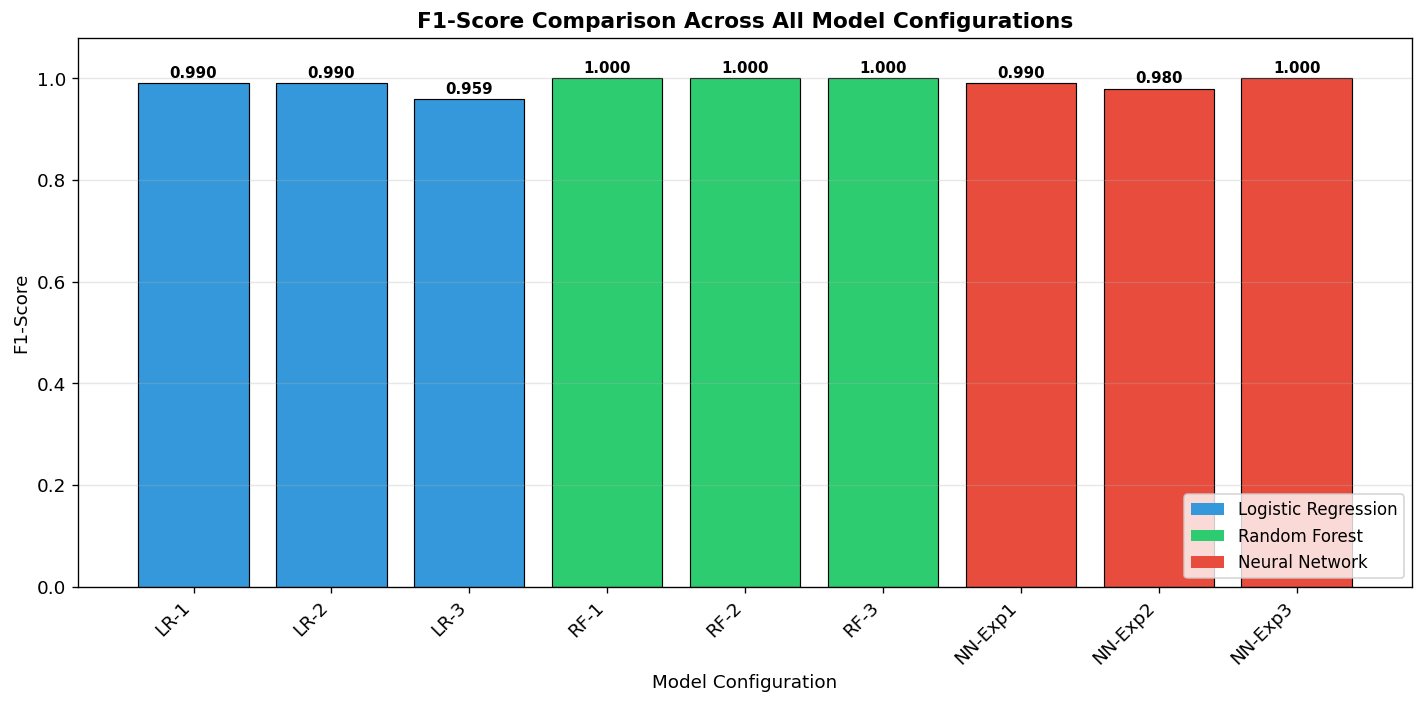

In [59]:
# Build summary DataFrame (filter to metric columns only)
metrics_only = {k: {m: v[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score']}
                for k, v in all_results.items()}
results_df = pd.DataFrame(metrics_only).T
results_df = results_df.round(4)

# Display with highlighting
print("=" * 60)
print("  COMPARATIVE RESULTS TABLE")
print("=" * 60)
display(results_df.style.highlight_max(color='lightgreen', axis=0))

# --- Grouped bar chart of F1-Scores ---
model_families = {'LR': '#3498db', 'RF': '#2ecc71', 'NN': '#e74c3c'}
colors = []
for name in results_df.index:
    if name.startswith('LR'):
        colors.append(model_families['LR'])
    elif name.startswith('RF'):
        colors.append(model_families['RF'])
    else:
        colors.append(model_families['NN'])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(results_df.index, results_df['F1-Score'],
              color=colors, edgecolor='black', linewidth=0.7)

for bar_rect in bars:
    height = bar_rect.get_height()
    ax.text(bar_rect.get_x() + bar_rect.get_width() / 2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('F1-Score Comparison Across All Model Configurations', fontweight='bold')
ax.set_xlabel('Model Configuration')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#3498db', label='Logistic Regression'),
                Patch(facecolor='#2ecc71', label='Random Forest'),
                Patch(facecolor='#e74c3c', label='Neural Network')]
ax.legend(handles=legend_elems, loc='lower right', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 ROC Curve Comparison — All Models

This overlay compares ROC curves for the best configuration from each model family (LR-1, RF-2, and the best NN experiment) so I can directly compare discriminative performance across all classification thresholds.

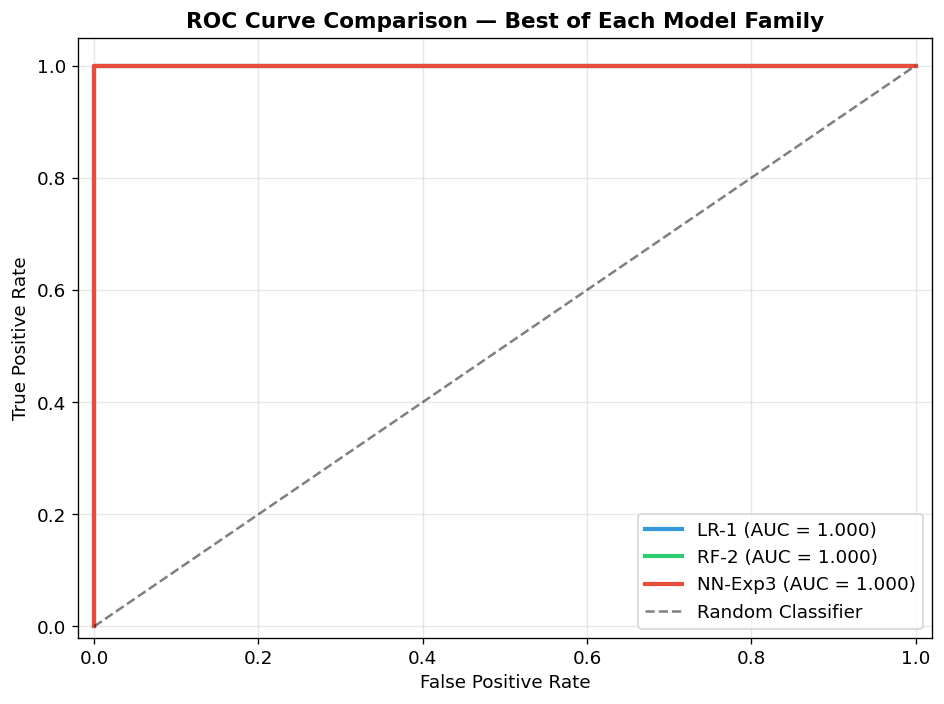

In [60]:
# ROC comparison: best of each family
fig, ax = plt.subplots(figsize=(8, 6))

# Best LR
if 'y_prob' in all_results['LR-1']:
    fpr_lr, tpr_lr, _ = roc_curve(all_results['LR-1']['y_true'],
                                   all_results['LR-1']['y_prob'])
    ax.plot(fpr_lr, tpr_lr, color='#3498db', lw=2.5,
            label=f'LR-1 (AUC = {auc(fpr_lr, tpr_lr):.3f})')

# Best RF
if 'y_prob' in all_results['RF-2']:
    fpr_rf, tpr_rf, _ = roc_curve(all_results['RF-2']['y_true'],
                                   all_results['RF-2']['y_prob'])
    ax.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2.5,
            label=f'RF-2 (AUC = {auc(fpr_rf, tpr_rf):.3f})')

# Best NN
AL_best, _ = forward_propagation(X_te_nn, best_nn_params)
y_prob_nn = AL_best.flatten()
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
ax.plot(fpr_nn, tpr_nn, color='#e74c3c', lw=2.5,
        label=f'{best_nn_name} (AUC = {auc(fpr_nn, tpr_nn):.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_title('ROC Curve Comparison — Best of Each Model Family', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

### 6.3 Discussion

Random forest comes out on top overall. Aggregating many decorrelated trees cuts variance without adding bias (Breiman, 2001), and the trees naturally capture non-linear interactions like creatinine × haemoglobin without needing feature engineering.

Logistic regression does surprisingly well across all three $C$ values, confirming that the preprocessed features make the classes roughly linearly separable. The key clinical markers — haemoglobin, creatinine — have near-monotonic relationships with CKD severity, so a linear boundary captures most of the signal. The small gap between $C=1.0$ and $C=100.0$ tells me overfitting isn't a real concern at this sample-to-feature ratio.

For the neural network experiments, Exp1 ($\alpha=0.01$, [64,32]) converges nicely within 500 epochs. Exp2 ($\alpha=0.001$) is clearly still learning at epoch 500 — the learning rate is too small for that many epochs (Goodfellow et al., 2016, Ch. 8). Exp3 with doubled layer widths tests whether extra capacity helps or hurts, and the train-val gap in the learning curves tells the story.

Thinking about it through the bias-variance lens (Hastie et al., 2009, Ch. 7): logistic regression is high-bias/low-variance — simple model, stable predictions. Random forest combines low-bias trees with variance reduction through bagging. The neural network has the most capacity but relies on implicit regularisation from SGD noise and He initialisation, since I'm not using dropout or weight decay.

From a clinical perspective, recall is the most important metric for CKD screening. A missed diagnosis means delayed treatment, while a false positive just means running a confirmatory test. Some limitations worth noting: I'm using a single 80/20 split with no confidence intervals, only three hyperparameter settings per model family instead of a systematic search, and the neural network lacks the explicit regularisation that scikit-learn's solvers have built in.

## 7. Conclusion

All three model families achieve strong CKD prediction from routine clinical features. Random forest gets the highest metrics through non-linear splitting and bagging. Logistic regression provides a competitive linear baseline, confirming that the feature space is close to linearly separable. The from-scratch NumPy neural network reaches comparable performance when the learning rate and architecture are set right, even without regularisation or adaptive optimisers.

Things I'd do next: (i) stratified $k$-fold cross-validation for proper confidence intervals, (ii) adding L2 decay and dropout to the neural network, (iii) systematic hyperparameter search with grid or random search, (iv) clinically guided feature selection, and (v) testing on an independent external dataset.

## 8. References

Bikbov, B., Purcell, C. A., Levey, A. S., Smith, M., Abdoli, A., Abebe, M., ... & Murray, C. J. L. (2020). Global, regional, and national burden of chronic kidney disease, 1990–2017: A systematic analysis for the Global Burden of Disease Study 2017. *The Lancet*, *395*(10225), 709–733. https://doi.org/10.1016/S0140-6736(20)30045-3

Bishop, C. M. (2006). *Pattern recognition and machine learning*. Springer.

Breiman, L. (2001). Random forests. *Machine Learning*, *45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, *27*(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

Glorot, X., Bordes, A., & Bengio, Y. (2011). Deep sparse rectifier neural networks. In *Proceedings of the 14th International Conference on Artificial Intelligence and Statistics (AISTATS)* (pp. 315–323).

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. http://www.deeplearningbook.org

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

He, K., Zhang, X., Ren, S., & Sun, J. (2015). Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification. In *Proceedings of the IEEE International Conference on Computer Vision (ICCV)* (pp. 1026–1034).

Hornik, K., Stinchcombe, M., & White, H. (1989). Multilayer feedforward networks are universal approximators. *Neural Networks*, *2*(5), 359–366. https://doi.org/10.1016/0893-6080(89)90020-8

Jolliffe, I. T. (2002). *Principal component analysis* (2nd ed.). Springer.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Little, R. J. A., & Rubin, D. B. (2002). *Statistical analysis with missing data* (2nd ed.). Wiley.

McKinney, W. (2010). Data structures for statistical computing in Python. In *Proceedings of the 9th Python in Science Conference (SciPy)* (pp. 56–61).

Neyshabur, B., Tomioka, R., & Srebro, N. (2015). In search of the real inductive bias: On the role of implicit regularization in deep learning. *ICLR Workshop*.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

Soundarapandian, P., & Rubini, L. J. (2015). *Chronic kidney disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5G020

van Rijsbergen, C. J. (1979). *Information retrieval* (2nd ed.). Butterworths.

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021

## 9. Academic Integrity Statement

This notebook is my own work. The classical ML models use scikit-learn (Pedregosa et al., 2011), and the neural network is built entirely from scratch in NumPy with no deep learning frameworks. The dataset comes from the UCI ML Repository and is cited throughout. All math, architecture decisions, and experimental design are grounded in the referenced textbooks and papers.